In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats, special



data = pd.read_csv('Data/numerical_train_cleaned.csv')
X = data.drop('SalePrice', axis=1)
y = data['SalePrice']

data

,GrLivArea,1stFlrSF,2ndFlrSF,TotalBsmtSF,BsmtUnfSF,BsmtFinSF1,BsmtFinSF2,LotArea,LotFrontage,GarageArea,...,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,SalePrice
0,1710,856,854,856,150,706,0,8450,65.0,548,...,1,0,2,1,3,1,8,0,2,208500
1,1262,1262,0,1262,284,978,0,9600,80.0,460,...,0,1,2,0,3,1,6,1,2,181500
2,1786,920,866,920,434,486,0,11250,68.0,608,...,1,0,2,1,3,1,6,1,2,223500
3,1717,961,756,756,540,216,0,9550,60.0,642,...,1,0,1,0,3,1,7,1,3,140000
4,2198,1145,1053,1145,490,655,0,14260,84.0,836,...,1,0,2,1,4,1,9,1,3,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,1647,953,694,953,953,0,0,7917,62.0,460,...,0,0,2,1,3,1,7,1,2,175000
1408,2073,2073,0,1542,589,790,163,13175,85.0,500,...,1,0,2,0,3,1,7,2,2,210000
1409,2340,1188,1152,1152,877,275,0,9042,66.0,252,...,0,0,2,0,4,1,9,2,1,266500
1410,1078,1078,0,1078,0,49,1029,9717,68.0,240,...,1,0,1,0,2,1,5,0,1,142125


# Mutal Information score and Correlation
for feature reduction

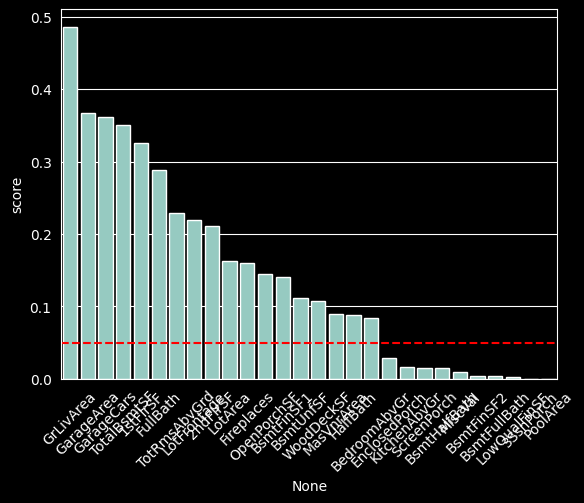

In [38]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X, y)
mi_series = pd.Series(mi, index=X.columns, name='score').sort_values(ascending=False)

sns.barplot(x=mi_series.index, y=mi_series.sort_values(ascending=False))
plt.xticks(rotation=45)
plt.axhline(y=0.05, color='r', linestyle='--')
plt.show()

In [39]:
selected_X = X[mi_series[mi_series.values > 0.05].keys()]

selected_X

,GrLivArea,GarageArea,GarageCars,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,LotFrontage,2ndFlrSF,LotArea,Fireplaces,OpenPorchSF,BsmtFinSF1,BsmtUnfSF,WoodDeckSF,MasVnrArea,HalfBath,BedroomAbvGr
0,1710,548,2,856,856,2,8,65.0,854,8450,0,61,706,150,0,196.0,1,3
1,1262,460,2,1262,1262,2,6,80.0,0,9600,1,0,978,284,298,0.0,0,3
2,1786,608,2,920,920,2,6,68.0,866,11250,1,42,486,434,0,162.0,1,3
3,1717,642,3,756,961,1,7,60.0,756,9550,1,35,216,540,0,0.0,0,3
4,2198,836,3,1145,1145,2,9,84.0,1053,14260,1,84,655,490,192,350.0,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,1647,460,2,953,953,2,7,62.0,694,7917,1,40,0,953,0,0.0,1,3
1408,2073,500,2,1542,2073,2,7,85.0,0,13175,2,0,790,589,349,119.0,0,3
1409,2340,252,1,1152,1188,2,9,66.0,1152,9042,2,60,275,877,0,0.0,0,4
1410,1078,240,1,1078,1078,1,5,68.0,0,9717,0,0,49,0,366,0.0,0,2


## Correlation

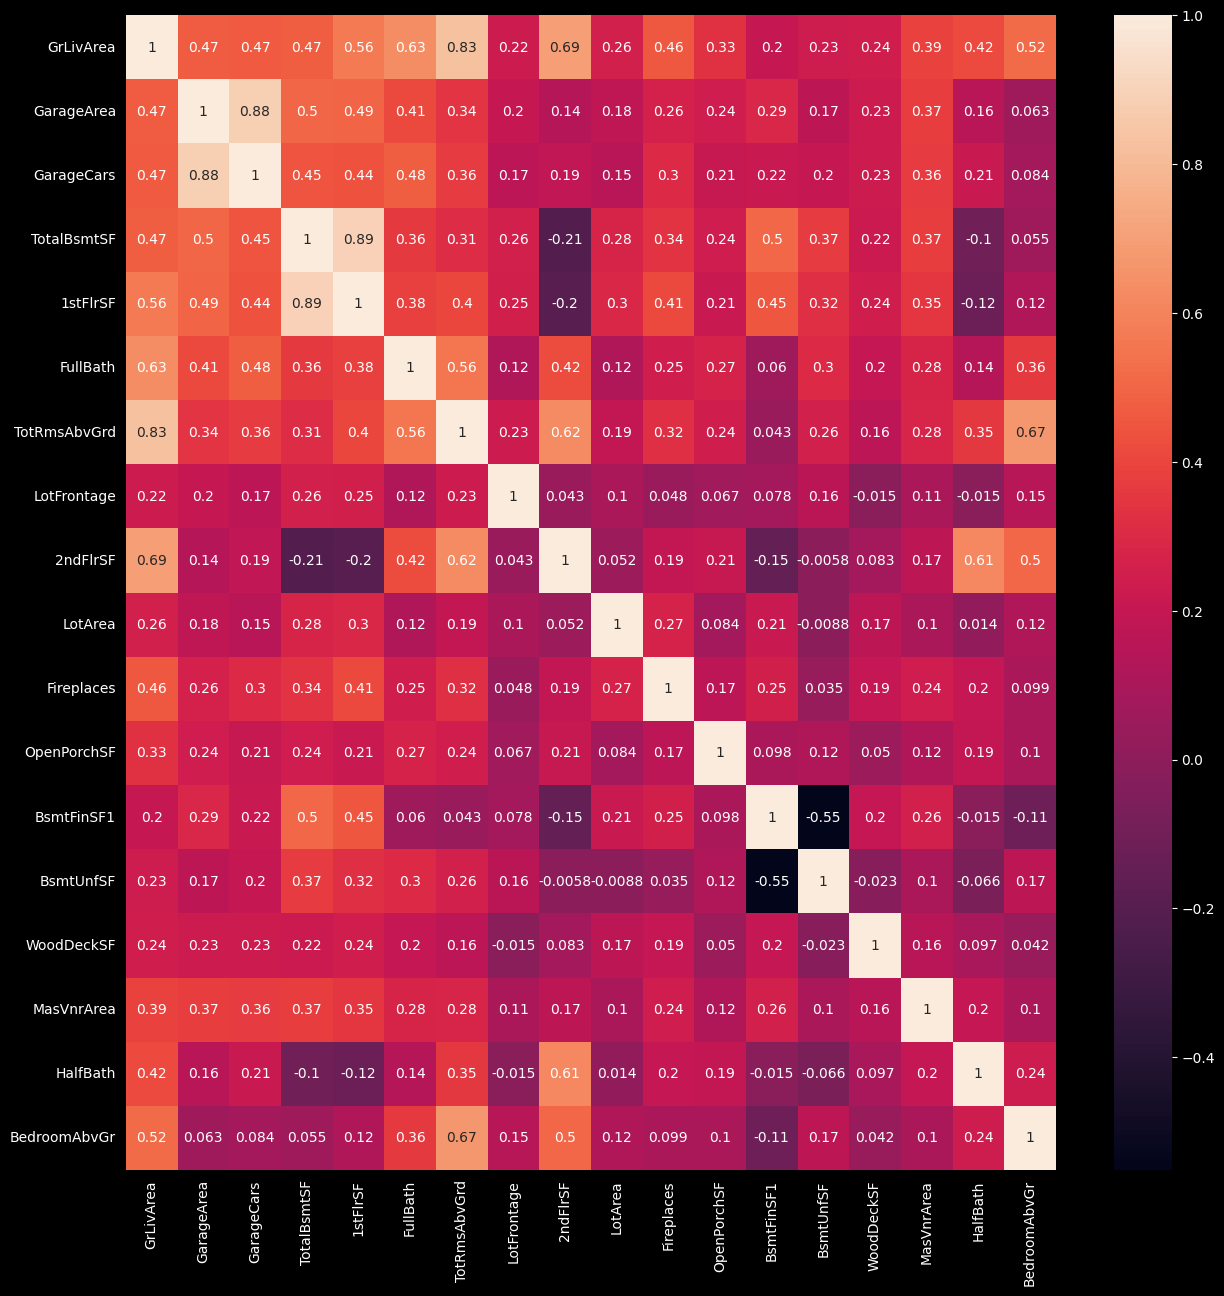

In [40]:
corr_mtx = selected_X.corr(method='pearson')

plt.figure(figsize=(15,15))
sns.heatmap(corr_mtx, annot=True)
plt.show()

In [41]:
current_X = selected_X.drop(['GarageCars', 'TotRmsAbvGrd'], axis=1)

current_X

,GrLivArea,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,LotFrontage,2ndFlrSF,LotArea,Fireplaces,OpenPorchSF,BsmtFinSF1,BsmtUnfSF,WoodDeckSF,MasVnrArea,HalfBath,BedroomAbvGr
0,1710,548,856,856,2,65.0,854,8450,0,61,706,150,0,196.0,1,3
1,1262,460,1262,1262,2,80.0,0,9600,1,0,978,284,298,0.0,0,3
2,1786,608,920,920,2,68.0,866,11250,1,42,486,434,0,162.0,1,3
3,1717,642,756,961,1,60.0,756,9550,1,35,216,540,0,0.0,0,3
4,2198,836,1145,1145,2,84.0,1053,14260,1,84,655,490,192,350.0,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,1647,460,953,953,2,62.0,694,7917,1,40,0,953,0,0.0,1,3
1408,2073,500,1542,2073,2,85.0,0,13175,2,0,790,589,349,119.0,0,3
1409,2340,252,1152,1188,2,66.0,1152,9042,2,60,275,877,0,0.0,0,4
1410,1078,240,1078,1078,1,68.0,0,9717,0,0,49,0,366,0.0,0,2


# Shapiro Test for normality and Transformations

In [42]:
def check_normality(data, column_name="Data", plot=False):
    stat, p_value = stats.shapiro(data)

    print(f"--- Normality Test: {column_name} ---")
    print(f"W-Statistic: {stat:.4f}")
    print(f"P-Value: {p_value:.4f}")

    if p_value > 0.05:
        print("Result: Fail to reject the null hypothesis (Data appears normally distributed).")
    else:
        print("Result: Reject the null hypothesis (Data does not appear normally distributed).")

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Histogram with KDE
        sns.histplot(data, kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title(f'Histogram of {column_name}')

        # Probability Plot (Q-Q Plot)
        stats.probplot(data, dist="norm", plot=axes[1])
        axes[1].set_title(f'Probability Plot (Q-Q) of {column_name}')

        plt.tight_layout()
        plt.show()

    return p_value, stat


for c in current_X.columns:
    check_normality(current_X, c)


--- Normality Test: GrLivArea ---
W-Statistic: 0.2526
P-Value: 0.0000
Result: Reject the null hypothesis (Data does not appear normally distributed).
--- Normality Test: GarageArea ---
W-Statistic: 0.2526
P-Value: 0.0000
Result: Reject the null hypothesis (Data does not appear normally distributed).
--- Normality Test: TotalBsmtSF ---
W-Statistic: 0.2526
P-Value: 0.0000
Result: Reject the null hypothesis (Data does not appear normally distributed).
--- Normality Test: 1stFlrSF ---
W-Statistic: 0.2526
P-Value: 0.0000
Result: Reject the null hypothesis (Data does not appear normally distributed).
--- Normality Test: FullBath ---
W-Statistic: 0.2526
P-Value: 0.0000
Result: Reject the null hypothesis (Data does not appear normally distributed).
--- Normality Test: LotFrontage ---
W-Statistic: 0.2526
P-Value: 0.0000
Result: Reject the null hypothesis (Data does not appear normally distributed).
--- Normality Test: 2ndFlrSF ---
W-Statistic: 0.2526
P-Value: 0.0000
Result: Reject the null hypo

/home/franio/Desktop/Uczenie_maszynowe/venv/lib/python3.11/site-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


## BOXCOX transformation to make it noramal

In [43]:

normal_X = pd.DataFrame()
for col in current_X.columns:
    normal_X[col], _  = stats.boxcox(selected_X[col] + 1)

normal_X

,GrLivArea,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,LotFrontage,2ndFlrSF,LotArea,Fireplaces,OpenPorchSF,BsmtFinSF1,BsmtUnfSF,WoodDeckSF,MasVnrArea,HalfBath,BedroomAbvGr
0,6.484482,204.568536,12.276756,4.327804,1.712883,28.197481,4.627816,10.530298,0.000000,4.355158,16.903289,21.138135,0.000000,3.085711,0.365747,2.892621
1,6.254370,177.372068,13.474639,4.471184,1.712883,32.996821,0.000000,10.702427,0.619700,0.000000,18.699477,29.432997,4.825198,0.000000,0.000000,2.892621
2,6.517207,222.635916,12.493559,4.355038,1.712883,29.178737,4.634014,10.917398,0.619700,3.949975,15.020666,36.539181,0.000000,3.026981,0.365747,2.892621
3,6.487558,232.723689,11.909156,4.371371,0.911265,26.535234,4.573239,10.695368,0.619700,3.754613,11.501887,40.809166,0.000000,0.000000,0.000000,2.892621
4,6.672682,288.529149,13.167246,4.435987,1.712883,34.235344,4.719783,11.240851,0.619700,4.707605,16.510727,38.854959,4.510481,3.250012,0.365747,3.829907
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,6.456189,177.372068,12.600456,4.368248,1.712883,27.204315,4.534451,10.442684,0.619700,3.897520,0.000000,54.259988,0.000000,0.000000,0.365747,2.892621
1408,6.628948,189.845459,14.123303,4.643327,1.712883,34.542537,0.000000,11.132606,0.921762,0.000000,17.506103,42.635241,4.936409,2.926567,0.000000,2.892621
1409,6.719337,108.537050,13.186360,4.449381,1.712883,28.525856,4.758538,10.621555,0.921762,4.337072,12.474389,52.055056,0.000000,0.000000,0.000000,3.829907
1410,6.133974,104.293745,12.979172,4.413928,0.911265,29.178737,0.000000,10.718806,0.000000,0.000000,6.697033,0.000000,4.969695,0.000000,0.000000,1.945065


# Additional Statistic and Visualizations

## Yet Another MI test

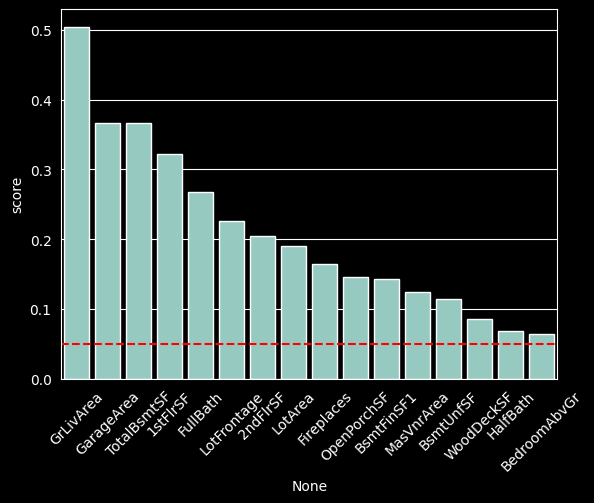

In [44]:
mi = mutual_info_regression(normal_X, y)
mi_series = pd.Series(mi, index=normal_X.columns, name='score').sort_values(ascending=False)

sns.barplot(x=mi_series.index, y=mi_series.sort_values(ascending=False))
plt.xticks(rotation=45)
plt.axhline(y=0.05, color='r', linestyle='--')
plt.show()

## PCA

In [45]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def calc_PCA(data):
    pca = PCA(n_components=4)
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    data_scaled = pd.DataFrame(data_scaled, columns=data.columns, index=data.index)
    pca.fit(data_scaled)

    df_components = pd.DataFrame()
    df_PCA = pd.DataFrame(pca.components_.T, index=data_scaled.columns, columns = ['PC1', 'PC2', 'PC3', 'PC4']).sort_values(by='PC1', ascending=False)

    return df_PCA

df_PCA = calc_PCA(normal_X)
df_PCA

,PC1,PC2,PC3,PC4
GrLivArea,0.408208,0.225810,-0.040578,0.099601
1stFlrSF,0.359137,-0.327533,0.104886,0.076609
TotalBsmtSF,0.338799,-0.342321,0.112487,-0.014946
FullBath,0.332178,0.150273,0.064420,-0.155622
GarageArea,0.318051,-0.094781,-0.084624,-0.144305
Fireplaces,0.270884,-0.001598,-0.168263,-0.002396
LotArea,0.252649,-0.102024,-0.002217,0.495423
OpenPorchSF,0.245838,0.089062,-0.036493,-0.308371
MasVnrArea,0.221494,-0.093520,-0.146981,-0.341878
BedroomAbvGr,0.199134,0.291612,0.085688,0.408924


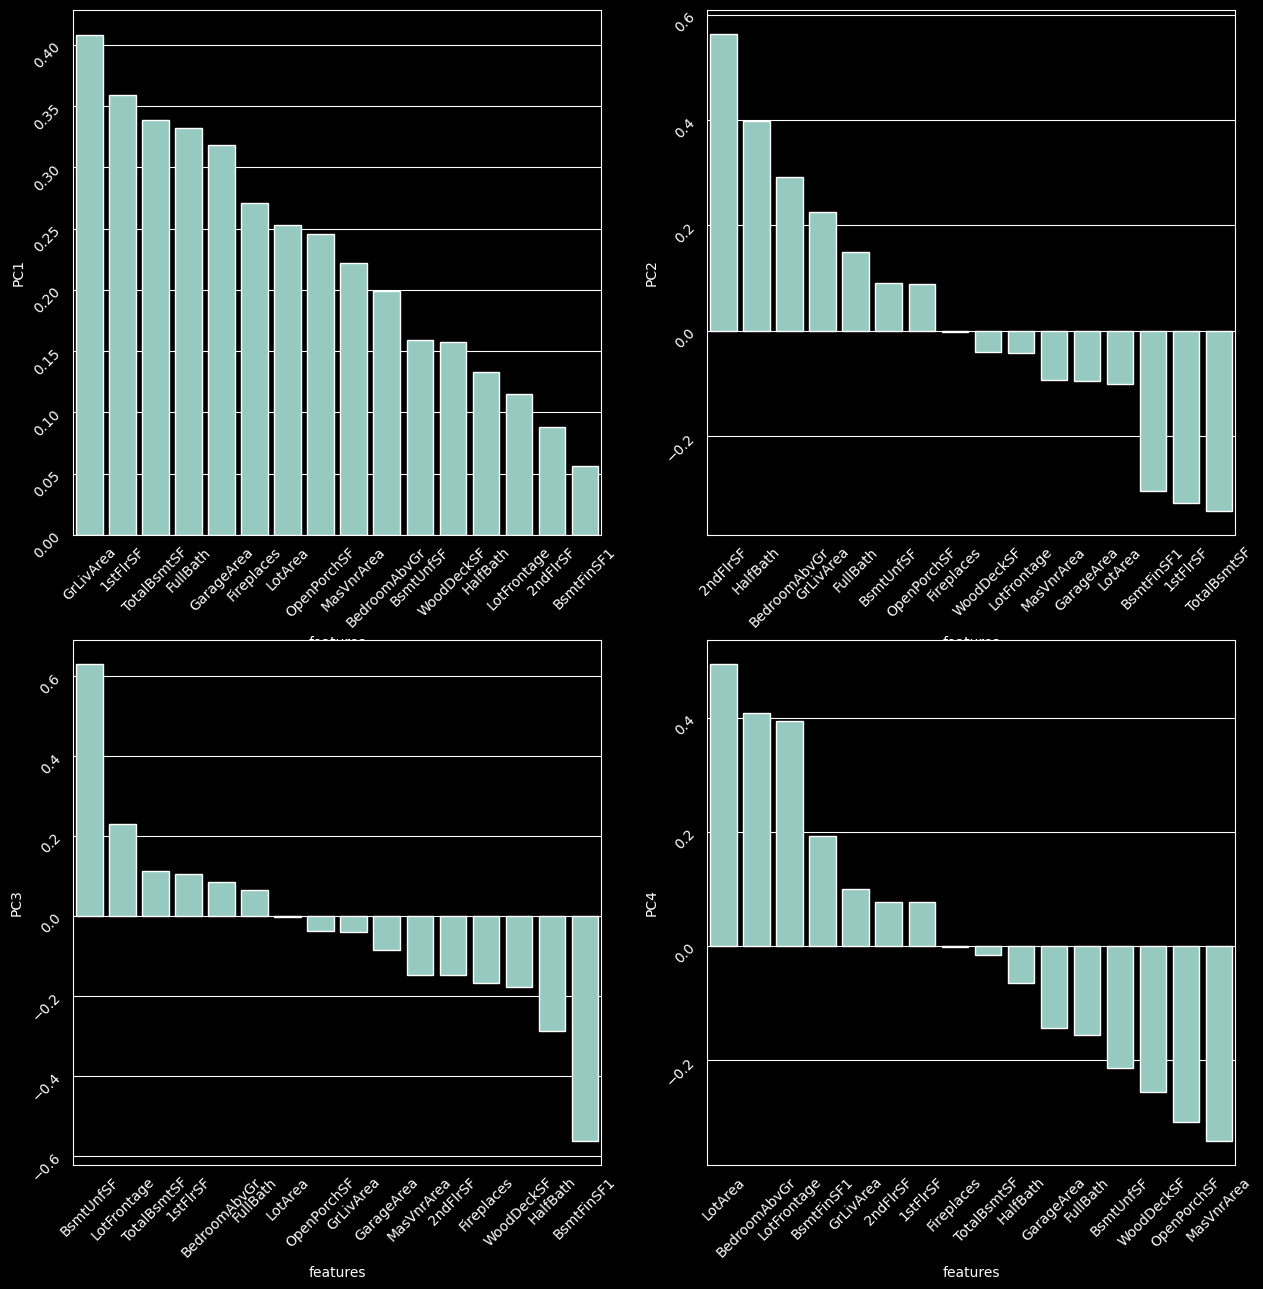

In [46]:
fig, ax = plt.subplots(2,2, figsize = (15,15))
ax=ax.flatten()

for idx, col in enumerate(df_PCA.columns):
    df_PCA.sort_values(by=col, ascending=False, inplace=True)
    sns.barplot(data = df_PCA, x=df_PCA.index, y=col, ax=ax[idx])
    ax[idx].tick_params(rotation=45)
    ax[idx].set_xlabel("features")


plt.show()

# Feature Enginnering for Feature reduction

In [49]:
final_X = pd.DataFrame()


#Enginnered Features
final_X['Living_Area'] = normal_X['GrLivArea'] + normal_X['1stFlrSF'] + normal_X['TotalBsmtSF'] + normal_X['LotArea'] + normal_X['2ndFlrSF']
final_X['OpenSF'] = normal_X['OpenPorchSF'] + normal_X['WoodDeckSF'] + normal_X['MasVnrArea']

l_idx_col = ['BsmtFinSF1', 'HalfBath', 'WoodDeckSF', 'Fireplaces']
final_X['Luxury_index'] = normal_X[l_idx_col].mean(axis=1)

c_idx_col = ['LotArea', 'BedroomAbvGr', 'LotFrontage']
final_X['Comf_idx'] = normal_X[c_idx_col].mean(axis=1)

# Kept Features
final_X['FullBath'] = normal_X['FullBath']
final_X['LotFrontage'] = normal_X['LotFrontage']

final_X

,Living_Area,OpenSF,Luxury_index,Comf_idx,FullBath,LotFrontage
0,38.247157,7.440869,4.317259,13.873467,1.712883,28.197481
1,34.902620,4.825198,6.036094,15.530623,1.712883,32.996821
2,38.917216,6.976956,4.001528,14.329585,1.712883,29.178737
3,38.036693,3.754613,3.030397,13.374408,0.911265,26.535234
4,40.236550,12.468098,5.501664,16.435368,1.712883,34.235344
...,...,...,...,...,...,...
1407,38.402028,3.897520,0.246362,13.513207,1.712883,27.204315
1408,36.528185,7.862977,5.841068,16.189255,1.712883,34.542537
1409,39.735171,4.337072,3.349038,14.325773,1.712883,28.525856
1410,34.245881,4.969695,2.916682,13.947536,0.911265,29.178737
